**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset?resource=download

In [27]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
# load in data
df = pd.read_csv("student_lifestyle_performance_dataset.csv")
df.head()

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77


2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Branch                 1000 non-null   str    
 2   Study_Hours_per_Day    1000 non-null   float64
 3   Sleep_Hours            1000 non-null   float64
 4   Screen_Time_Hours      1000 non-null   float64
 5   Gym_Hours_per_Week     1000 non-null   float64
 6   Diet_Type              1000 non-null   str    
 7   Attendance_Percentage  1000 non-null   float64
 8   Stress_Level_1_to_10   1000 non-null   float64
 9   Residence              1000 non-null   str    
 10  Internal_Marks         1000 non-null   float64
 11  CGPA                   1000 non-null   float64
dtypes: float64(8), int64(1), str(3)
memory usage: 93.9 KB


In [30]:
df.describe()

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.898000,4.037970,6.525030,4.95191,7.311910,80.084340,4.582850,65.922380,7.319300
std,2.603916,1.434691,1.205664,1.97294,4.949333,8.578242,2.024595,10.123247,0.953812
min,17.000000,0.500000,3.000000,1.00000,0.000000,54.660000,1.000000,35.000000,4.000000
25%,19.000000,3.020000,5.710000,3.49000,3.445000,74.307500,3.095000,59.330000,6.690000
50%,21.000000,4.090000,6.515000,4.95500,6.975000,80.210000,4.540000,65.600000,7.300000
75%,23.000000,5.030000,7.380000,6.37250,10.780000,86.165000,5.962500,72.547500,7.990000
max,25.000000,8.050000,10.000000,10.84000,21.000000,100.000000,10.000000,93.930000,10.000000


- pre-cleaed data set
- 1k rows
- pretty good spread on all num varables. no log needed
- caterogical / one hot endcode the diet type, residecne, branch
- make my target variable teh CGPA this is on about range 4-10

3. Split the sample into an ~80% training set and a ~20% test set.


In [31]:
#make list of all category cols
categorys = ['Branch', 'Diet_Type', 'Residence']
#make dummies of all the categoricial features
cat_dummies = pd.get_dummies(df[categorys], drop_first=True)
#drop first ture since inclusing intercept later
print(cat_dummies.columns.tolist())

['Branch_Civil', 'Branch_ECE', 'Branch_Electrical', 'Branch_IT', 'Branch_Mechanical', 'Diet_Type_Veg', 'Residence_Hosteller']


In [32]:
# make list of just the numerical features
numeric_cols = ['Study_Hours_per_Day', 'Sleep_Hours', 'Screen_Time_Hours', 'Gym_Hours_per_Week',
                 'Attendance_Percentage', 'Stress_Level_1_to_10', 'Internal_Marks']

# Define X and y
X = df[numeric_cols] + cat_dummies
#target is log price
y = df['CGPA']

# splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.


In [33]:
#first model - numeric 
X_num = df[numeric_cols]
#split
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split( X_num, y, test_size=0.2, random_state=42)
#fit in trinaing 
model_num = LinearRegression()
model_num.fit(X_train_num, y_train_num)
#predict
y_pred_num = model_num.predict(X_test_num)
#evaluate
r2_num_train = r2_score(y_train_num, model_num.predict(X_train_num))
r2_num_test = r2_score(y_test_num, y_pred_num)
rmse_num = np.sqrt(mean_squared_error(y_test_num, y_pred_num))
print(f"Training R²:{r2_num_train}")
print(f"Test R²:{r2_num_test}")
print(f"Test RMSE: {rmse_num}")


Training R²:0.838606085034945
Test R²:0.8786338064027739
Test RMSE: 0.35047602287365204


In [34]:
#second model - categorical  
X_cat = cat_dummies
#split
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y, test_size=0.2, random_state=42)
#fit in trinaing 
model_cat = LinearRegression()
model_cat.fit(X_train_cat, y_train_cat)
#predict
y_pred_cat = model_cat.predict(X_test_cat)
#evaluate
r2_cat_train = r2_score(y_train_cat, model_cat.predict(X_train_cat))
r2_cat_test = r2_score(y_test_cat, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test_cat, y_pred_cat))
print(f"Training R²:{r2_cat_train}")
print(f"Test R²:{r2_cat_test}")
print(f"Test RMSE: {rmse_cat}")


Training R²:0.015811550798213836
Test R²:-0.0006423241188648898
Test RMSE: 1.0063496047379135


In [35]:
# third model - combined  
X_combined = pd.concat([df[numeric_cols], cat_dummies], axis=1)
X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(X_combined, y, test_size=0.2, random_state=42)
model_comb = LinearRegression()
model_comb.fit(X_train_comb, y_train_comb)
y_pred_comb = model_comb.predict(X_test_comb)
r2_comb_train = r2_score(y_train_comb, model_comb.predict(X_train_comb))
r2_comb_test = r2_score(y_test_comb, y_pred_comb)
rmse_comb = np.sqrt(mean_squared_error(y_test_comb, y_pred_comb))

# FIXED: print the comb variables, not the cat ones
print(f"Training R²:{r2_comb_train}")
print(f"Test R²:{r2_comb_test}")
print(f"Test RMSE:{rmse_comb}")

Training R²:0.8397170524295905
Test R²:0.8799416423103951
Test RMSE:0.348582552204275


In [36]:
# compare all 3 models 
print("Model 1 Test R²:", r2_num_test)
print("Model 2 Test R²:", r2_cat_test)
print("Model 3 Test R²:", r2_comb_test)


print("Model 1 Test RMSE:", rmse_num)
print("Model 2 Test RMSE:", rmse_cat)
print("Model 3 Test RMSE:", rmse_comb)

Model 1 Test R²: 0.8786338064027739
Model 2 Test R²: -0.0006423241188648898
Model 3 Test R²: 0.8799416423103951
Model 1 Test RMSE: 0.35047602287365204
Model 2 Test RMSE: 1.0063496047379135
Model 3 Test RMSE: 0.348582552204275


5. Which model performed the best, and why?


The combined with numeric and catgorical prefromed the best but its mostly the numerica values that are doing it the best. now im goig to chekc for teh best ploynimical that is best since this can only be preformed on the nuerical vlaues adn becuase the r^2 for just catoagical was negative showing that it does not contribute that mcuh to helping the model get th best reult.

In [37]:
# PolynomialFeatures makes new columns from the num cols and increases the polynomial to see which
# best degree makes the model fit the best
#cant do it on categorical though

#make x the numeircla cols only
X = df[numeric_cols]
#still keep y as the log price target variable
y = df['CGPA']

#run this look for teh degrere values of 1 to 5
degrees = range(1, 6)
#list that saves results
results_poly = []

#loop thgouht each degree value adn save outputs
for deg in degrees:
    # create polynomial features up to the 5th degree
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    # include_bias=False bc linreg adds its own intercept
    
    # transform the num features
    X_poly = poly.fit_transform(X)
    
    # split testing adn training
    X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)
    
    # fit to training data
    model_poly = LinearRegression()
    model_poly.fit(X_train_p, y_train_p)
    
    # evaluate r^2 and rmse for testing and training
    r2_train = r2_score(y_train_p, model_poly.predict(X_train_p))
    r2_test  = r2_score(y_test_p,  model_poly.predict(X_test_p))
    rmse_test= np.sqrt(mean_squared_error(y_test_p, model_poly.predict(X_test_p)))
    n_features = X_poly.shape[1]
    
    #add all these results to the results list
    results_poly.append({
        'Degree': deg,
        'Num Features': n_features,
        'Train R²':round(r2_train, 4),
        'Test R²': round(r2_test, 4),
        'Test RMSE':round(rmse_test, 4)
    })

#save the results of the loop to a data frame so can read eaiser
poly_df = pd.DataFrame(results_poly)
print(poly_df)

   Degree  Num Features  Train R²   Test R²  Test RMSE
0       1             7    0.8386    0.8786     0.3505
1       2            35    0.8444    0.8688     0.3643
2       3           119    0.8623    0.8394     0.4031
3       4           329    0.9097    0.5206     0.6966
4       5           791    0.9894 -214.5574    14.7704


the first polynmal is going to be best. this data is best represent by a linear model. it actually gets worse with every increase in polynomial bc the data is genuintly pretty linear so its overfitting alot when increasing decreegs. 

/tmp/ipykernel_2312/3998397557.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


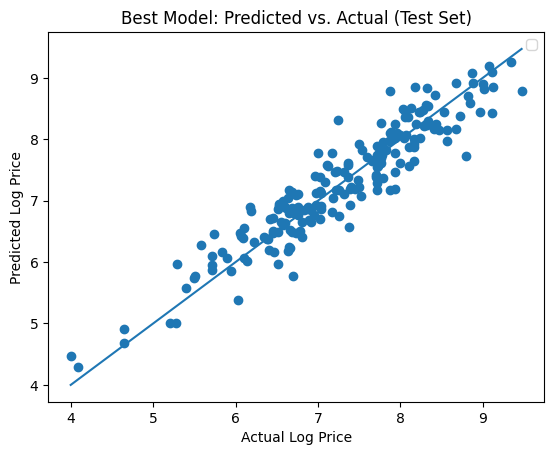

In [38]:
#look into acutal adn predicted adn the kde breakdown 
# im gonna use the combined model from above
#y_test_comb
#y_pred_comb

plt.scatter(y_test_comb, y_pred_comb)
plt.plot([y_test_comb.min(), y_test_comb.max()], [y_test_comb.min(), y_test_comb.max()])
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Best Model: Predicted vs. Actual (Test Set)')
plt.legend()
plt.show()

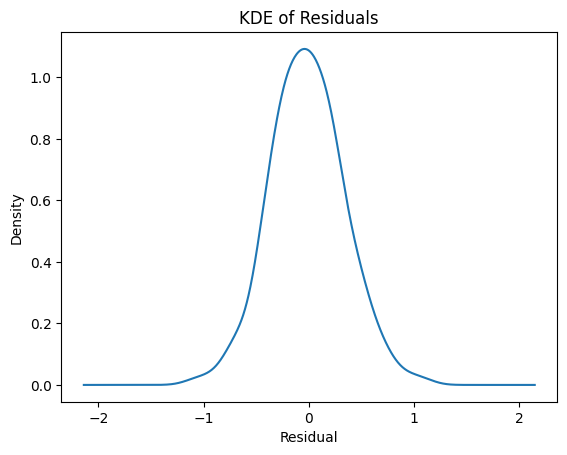

Mean residual:-0.014245547292411741
Std of residuals:0.3482913436816737


In [39]:
#calculateed the residuals
residuals = y_test_comb.values - y_pred_comb

pd.Series(residuals).plot.kde()
plt.xlabel('Residual')
plt.title('KDE of Residuals')
plt.show()

print(f"Mean residual:{residuals.mean()}")
print(f"Std of residuals:{residuals.std()}")

6. What did you learn?

the CGPA is best perdicted by the numericaly data of what the students are acutally doing like stufying and scoring rather then just characteristics adn demografics about there diet and study area. the real numbers predict better then tehse basic descrpibers of people in predicting the CGPA. this makes intuitive sense. the polynomial expansion was also useful in learning that each adding degree made the r^2 worse and was super overfitting. so this t=says that the regular plain linear was better represntation of teh data. theres no really true curved pattern its best straight. one limitaiton of this dataset as a whole though is that it was pre-cleaned and spesfically broadcasted to practice modeling relationships so this was currated with this intention. It is still helpful in learning but maybe if it were a more raw display of students there would be different outcomes. espially if more characteriics were added like school type or loaction etc.